#### 简单常微分方程求解

## 符号解

$$
\frac{dy}{dx} = -2y + 2x^2 + 2x,y(0) = 1
$$

In [11]:
import sympy as sp

x = sp.symbols('x')
y = sp.Function('y')(x)

eq = sp.Eq(y.diff(x),-2 * y + 2 * x**2 + 2 * x)

s = sp.dsolve(eq,ics = {y.subs(x,0): 1})
s = sp.simplify(s)
sp.pretty_print(s,use_unicode = True)


        2    -2⋅x
y(x) = x  + ℯ    


$$
y'' - 2y' + y = e^x,y(0) = 1,y'(0) = -1
$$

In [5]:

import sympy as sp

x = sp.symbols('x')
y = sp.Function('y')

eq = sp.Eq(y(x).diff(x,2) - 2 * y(x).diff(x) + y(x),sp.exp(x))
con = { y(0): 1, y(x).diff(x).subs(x,0): -1 }
s = sp.dsolve(eq,ics = con)
sp.pretty_print(s,use_unicode = True)


       ⎛  ⎛x    ⎞    ⎞  x
y(x) = ⎜x⋅⎜─ - 2⎟ + 1⎟⋅ℯ 
       ⎝  ⎝2    ⎠    ⎠   


$$
    u(t) = e^{-t} * cost, \\
    y^{(4)}(t) + 10y^{(3)}(t) + 35y''(t) + 50y'(t) + 24y(t) = u''(t), \\
    y(0) = 0,y'(0) = -1,y''(0) = 1,y'''(0) = 1
$$

In [16]:

import sympy as sp

t = sp.symbols('t')
y = sp.Function('y')(t)
u = sp.exp(-t) * sp.cos(t)

eq = sp.Eq(y.diff(t,4) + 10 * y.diff(t,3) + 35 * y.diff(t,2) + 50 * y.diff(t) + 24 * y,u.diff(t,2))
con = { y.subs(t,0): 0, y.diff(t).subs(t,0): -1, y.diff(t,2).subs(t,0): 1, y.diff(t,3).subs(t,0): 1 }

s = sp.dsolve(eq,ics = con)
s = sp.expand(s)
sp.pretty_print(s,use_unicode = True)


          -t             -t      -2⋅t       -3⋅t       -4⋅t
         ℯ  ⋅sin(t)   7⋅ℯ     9⋅ℯ       14⋅ℯ       19⋅ℯ    
y(t) = - ────────── - ───── + ─────── - ──────── + ────────
             5          3        2         5          30   


$$
\begin{cases}
    \frac{d\mathbf{x}}{dt} = \mathbf{Ax}, \\
    \mathbf{x}(0) = \left[1,1,1\right]^T
\end{cases} \\
\mathbf{x}(t) = \left[ x_1(t),x_2(t),x_3(t) \right]^T,\mathbf{A} = \left[ \begin{matrix} 3 & -1 & 1 \\ 2 & 0 & -1 \\ 1 & -1 & 2 \end{matrix} \right]
$$

In [6]:

import sympy as sp

t = sp.symbols('t')
x1,x2,x3 = sp.symbols('x1:4',cls = sp.Function)
x = sp.Matrix([x1(t),x2(t),x3(t)])
A = sp.Matrix([[3,-1,1],[2,0,-1],[1,-1,2]])

eq = x.diff(t) - A @ x
cons = { x1(0): 1,x2(0): 1,x3(0): 1 }
s = sp.dsolve(eq,ics = cons)
sp.pretty_print(s,use_unicode = True)


⎡           3⋅t    2⋅t                 3⋅t    2⋅t                 3⋅t    ⎤
⎢        4⋅ℯ      ℯ      1          2⋅ℯ      ℯ      5          2⋅ℯ      1⎥
⎢x₁(t) = ────── - ──── + ─, x₂(t) = ────── - ──── + ─, x₃(t) = ────── + ─⎥
⎣          3       2     6            3       2     6            3      3⎦


## 数值解(一阶常微分,高阶要化为一阶)

$$
\frac{dy}{dx} = -2y + 2x^2 + 2x,y(0) = 1
$$

x = [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7
 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7 2.8 2.9 3. ]
数值解 y = [1.         0.82873077 0.71032006 0.63881165 0.60932898 0.61787947
 0.66119421 0.73659696 0.84189652 0.97529888 1.13533527 1.32080314
 1.53071794 1.76427356 2.02081005 2.29978705 2.6007622  2.92337327
 3.26732372 3.63237077 4.01831564 4.42499558 4.85227734 5.30005184
 5.76822975 6.25673795 6.76551656 7.29451658 7.84369786 8.41302755
 9.00247875]


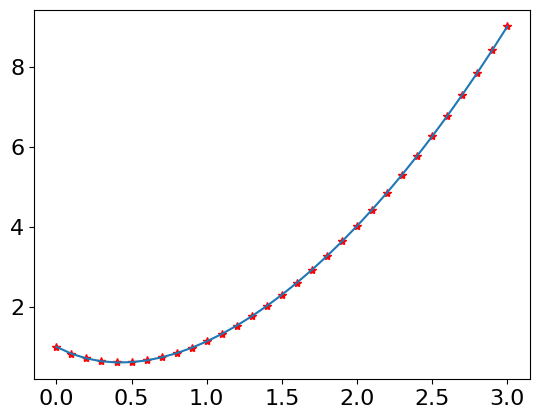

In [12]:

from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

dy = lambda y,x: -2 * y + 2 * x**2 + 2 * x
xx = np.linspace(0,3,31)
s2 = odeint(dy,1,xx)

print(f'x = {xx}')
print(f'数值解 y = {s2.flatten()}')

plt.figure()
plt.plot(xx,s2,'*',color = 'r')
plt.plot(xx,sp.lambdify(x,s.args[1],'numpy')(xx))
plt.show()


$$
    \begin{cases} 
        (1 - x)\frac{d^2y}{dx^2} = \frac{1}{5}\sqrt{1 + \left( \frac{dy}{dx} \right)^2} , ~~ 0 < x \leq 1, \\
        y(0) = 0,~~ y'(0) = 0.        
    \end{cases}
$$

令$ y_1 = y,y_2 = y' $
将高阶常微分方程化为一阶微分方程组

$$
    \begin{cases}
    y_1' = y_2, ~~~~~ y_1(0) = 0, \\
    y_2' = \frac{1}{5(1 - x)}\sqrt{1 + y_2^2}, ~~ y_2(0) = 0.
    \end{cases}
$$


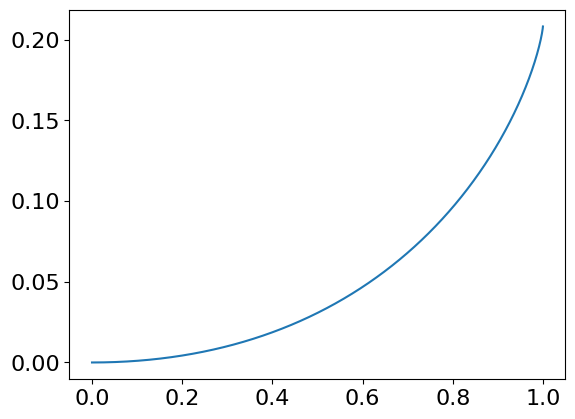

In [3]:
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt

model = lambda y,x: [y[1],np.sqrt(1 + y[1]**2) / (5 * (1 - x))]
xx = np.arange(0,1,0.00001)
ans = odeint(model,[0,0],xx)
plt.figure()
plt.rc('font',size = 16)
plt.plot(xx,ans[:,0])
plt.show()


#### 牛顿冷却定律

$$
    \frac{du}{dt} = -k(u - T)
$$

$
    其中, \\ 
    物体的温度 \, u = u(t), \\ 
    物体周围温度 \, T, \\
    t为时间, \\
    k为热传递系数,k > 0.
$




#### 微分方程2

$$
\begin{cases}
    \frac{dy}{dx} = \frac{v_0t - y}{1 - x} \\
    \frac{dx}{dt}\sqrt{1 + \left(\frac{dy}{dx}\right)^2} = 5v_0
\end{cases}
$$

可以通过对第一个式子求x求导，从而消掉t

$$ (1 - x)\frac{d^2y}{dx^2} = \frac{1}{5}\sqrt{1 + \left( \frac{dy}{dx} \right)^2} $$
随便来两个初值
y(0) = 0,y'(0) = 0

采用降阶法
令p = y',则y'' = \frac{dp}{dx}
$$
\begin{cases}
    (1 - x)\frac{dp}{dx} = \frac{1}{5}\sqrt{1 + p^2}, 0 \leq x \leq 1, \\
    p(0) = 0
\end{cases}
$$

分离变量积分并化简

$$ p + \sqrt{1 + p^2} = (1 - x)^{-\frac{1}{5}} $$
因为
$$ -p + \sqrt{1 + p^2} = \frac{1}{p + sqrt{1 + p^2}} = (1 - x)^{\frac{1}{5}} $$
相减得
$$
\begin{cases}
    \frac{dy}{dx} = p = \frac{1}{2}\[ (1 - x)^{-\frac{1}{5}} - (1 - x)^\frac{1}{5} \] , \\
    y(0) = 0
\end{cases}
$$